In [4]:
from ultralytics import YOLO
from IPython.display import display, Image

In [6]:
from dotenv import load_dotenv
import os

load_dotenv("apikeys.env")                 # reads ./.env by default
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
os.environ["ROBOFLOW_API_KEY"] = ROBOFLOW_API_KEY
print(ROBOFLOW_API_KEY)

yvdXnaL6YPTmM7fJov97


In [7]:
from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

In [5]:
!pwd

/teamspace/studios/this_studio/Workshop2


In [7]:
project = rf.workspace("large-benchmark-datasets").project("logistics-sz9jr")
dataset = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Logistics-2 in yolov8:: 100%|██████████| 189460/189460 [00:48<00:00, 3871.56it/s]


In [8]:
model = YOLO("best.pt")

In [8]:

# Validate the model
metrics = model.val(data = "/teamspace/studios/this_studio/Workshop2/Logistics-2/data.yaml")
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list contains map50-95 of each category

Ultralytics YOLOv8.2.103 🚀 Python-3.10.10 torch-2.7.1+cu128 CUDA:0 (Tesla T4, 14931MiB)
Model summary (fused): 168 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /teamspace/studios/this_studio/Workshop2/Logistics-2/valid/labels... 18988 images, 0 backgrounds, 0 corrupt: 100%|██████████| 18988/18988 [00:15<00:00, 1192.73it/s]

val: WARNING ⚠️ /teamspace/studios/this_studio/Workshop2/Logistics-2/valid/images/-Docker-1-Do_jpg.rf.5c00af35cf477fec60189674679ea214.jpg: 2 duplicate labels removed


val: New cache created: /teamspace/studios/this_studio/Workshop2/Logistics-2/valid/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1187/1187 [02:31<00:00,  7.82it/s]


                   all      18988      72322       0.71      0.594      0.644      0.443
               barcode        476        522      0.745      0.824      0.761      0.476
                   car       1953       2626      0.685      0.698      0.754      0.615
         cardboard box        837       9637      0.826      0.727       0.81      0.645
                  fire       2317       5747      0.685      0.261       0.41      0.191
              forklift       1894       2217      0.788      0.814      0.849       0.57
     freight container        369        691      0.457      0.384      0.369      0.257
                gloves        432        549      0.792       0.57      0.622      0.414
                helmet       1374       4467      0.734      0.532      0.594      0.335
                ladder        431        685      0.561      0.463      0.468      0.283
         license plate        662        806      0.647      0.355       0.45      0.371
                perso

array([    0.47641,     0.61548,     0.64474,     0.19066,     0.56971,     0.25738,     0.41448,     0.33473,     0.28321,     0.37085,      0.4183,     0.56139,     0.20488,     0.49069,     0.28766,     0.59596,     0.54355,     0.67626,     0.74507,     0.17004])

In [9]:
img_path = "/teamspace/studios/this_studio/Workshop2/Logistics-2/test/images/-_10_jpg.rf.7216b8fd23d002354ad6cdd0d7691cd5.jpg"
results = model.predict(source=img_path, conf=0.25, save=True)


image 1/1 /teamspace/studios/this_studio/Workshop2/Logistics-2/test/images/-_10_jpg.rf.7216b8fd23d002354ad6cdd0d7691cd5.jpg: 640x640 1 ladder, 1 person, 10.9ms
Speed: 7.8ms preprocess, 10.9ms inference, 890.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2


In [30]:
results[0].boxes.xyxy

tensor([[316.6084, 171.2482, 556.0833, 626.3577],
        [327.7481, 108.1212, 480.9223, 388.5036]], device='cuda:0')

In [31]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'barcode', 1: 'car', 2: 'cardboard box', 3: 'fire', 4: 'forklift', 5: 'freight container', 6: 'gloves', 7: 'helmet', 8: 'ladder', 9: 'license plate', 10: 'person', 11: 'qr code', 12: 'road sign', 13: 'safety vest', 14: 'smoke', 15: 'traffic cone', 16: 'traffic light', 17: 'truck', 18: 'van', 19: 'wood pallet'}
 obb: None
 orig_img: array([[[130, 105,  85],
         [141, 116,  96],
         [148, 123, 103],
         ...,
         [  0,  28,  17],
         [ 36,  65,  56],
         [105, 134, 125]],
 
        [[143, 118,  98],
         [139, 114,  94],
         [137, 112,  92],
         ...,
         [ 24,  58,  47],
         [ 18,  49,  40],
         [ 56,  87,  78]],
 
        [[148, 123, 103],
         [140, 115,  95],
         [135, 110,  90],
         ...,
         [ 27,  63,  51],
         [  0,  28,  18],
         [ 42,  76,  66]]

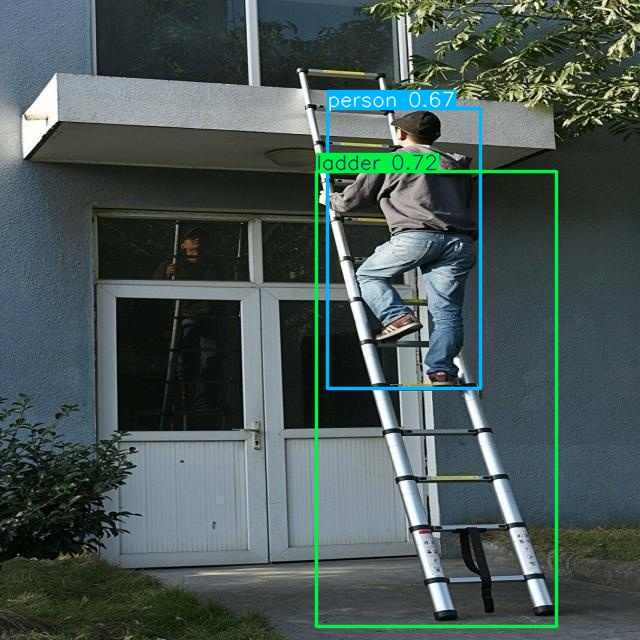

In [21]:
Image(filename='runs/detect/predict/-_10_jpg.rf.7216b8fd23d002354ad6cdd0d7691cd5.jpg', height=600)

In [24]:
!pwd

/teamspace/studios/this_studio/Workshop2


In [25]:
metrics = model.val(
    data="/teamspace/studios/this_studio/Workshop2/Logistics-2/data.yaml",  # path to data.yaml
    split="test",   # run evaluation on test split instead of val
    imgsz=640,
    conf=0.25
)

print(metrics)  # will include mAP50, mAP50-95, precision, recall, etc.

Ultralytics YOLOv8.2.103 🚀 Python-3.10.10 torch-2.7.1+cu128 CUDA:0 (Tesla T4, 14931MiB)


val: Scanning /teamspace/studios/this_studio/Workshop2/Logistics-2/test/labels... 9525 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9525/9525 [00:11<00:00, 814.48it/s]


val: New cache created: /teamspace/studios/this_studio/Workshop2/Logistics-2/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 596/596 [01:21<00:00,  7.30it/s]


                   all       9525      36721      0.714      0.605      0.685      0.505
               barcode        272        283      0.744       0.88      0.815      0.551
                   car       1000       1379      0.718      0.701      0.769      0.653
         cardboard box        443       4995      0.843       0.71      0.816      0.698
                  fire       1133       2793      0.677       0.25      0.453      0.255
              forklift        949       1103       0.77      0.811      0.848      0.587
     freight container        192        318      0.449      0.384      0.415      0.331
                gloves        226        256      0.837      0.699      0.801      0.562
                helmet        631       2170      0.754      0.549      0.664       0.41
                ladder        183        277      0.544      0.499      0.541      0.342
         license plate        292        359      0.617      0.362      0.512      0.455
                perso

In [10]:
def encode_response(results):
    """
    Convert Ultralytics YOLO results (list of Results) into JSON-friendly dict.
    Uses class names from the results array itself.
    """
    detections = []
    if not results:
        return {"detections": detections}

    r = results[0]   # one Results object
    boxes = r.boxes

    if boxes is None or len(boxes) == 0:
        return {"detections": detections}

    cls = boxes.cls.cpu().numpy().astype(int)
    conf = boxes.conf.cpu().numpy()
    xyxy = boxes.xyxy.cpu().numpy()

    # names mapping is in the result object
    names = r.names  

    for class_id, confidence, bbox in zip(cls, conf, xyxy):
        detections.append({
            "class_id": int(class_id),
            "class_name": names[class_id],
            "confidence": float(confidence),
            "bbox": bbox.tolist()  # [x1, y1, x2, y2]
        })

    return {"detections": detections}

In [11]:
encode_response(results)

{'detections': [{'class_id': 8,
   'class_name': 'ladder',
   'confidence': 0.7223952412605286,
   'bbox': [316.6083984375,
    171.2482147216797,
    556.0833129882812,
    626.3577270507812]},
  {'class_id': 10,
   'class_name': 'person',
   'confidence': 0.6694447994232178,
   'bbox': [327.74810791015625,
    108.12124633789062,
    480.92230224609375,
    388.5036315917969]}]}

In [28]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'barcode', 1: 'car', 2: 'cardboard box', 3: 'fire', 4: 'forklift', 5: 'freight container', 6: 'gloves', 7: 'helmet', 8: 'ladder', 9: 'license plate', 10: 'person', 11: 'qr code', 12: 'road sign', 13: 'safety vest', 14: 'smoke', 15: 'traffic cone', 16: 'traffic light', 17: 'truck', 18: 'van', 19: 'wood pallet'}
 obb: None
 orig_img: array([[[130, 105,  85],
         [141, 116,  96],
         [148, 123, 103],
         ...,
         [  0,  28,  17],
         [ 36,  65,  56],
         [105, 134, 125]],
 
        [[143, 118,  98],
         [139, 114,  94],
         [137, 112,  92],
         ...,
         [ 24,  58,  47],
         [ 18,  49,  40],
         [ 56,  87,  78]],
 
        [[148, 123, 103],
         [140, 115,  95],
         [135, 110,  90],
         ...,
         [ 27,  63,  51],
         [  0,  28,  18],
         [ 42,  76,  66]]

In [1]:
!python client.py --image /teamspace/studios/this_studio/Workshop2/Logistics-2/test/images/-_10_jpg.rf.7216b8fd23d002354ad6cdd0d7691cd5.jpg

INFO:root:Result: {'detections': [{'class_id': 8, 'class_name': 'ladder', 'confidence': 0.7223947048187256, 'bbox': [316.6083984375, 171.24810791015625, 556.0833129882812, 626.3577270507812]}, {'class_id': 10, 'class_name': 'person', 'confidence': 0.6694446802139282, 'bbox': [327.74810791015625, 108.1212158203125, 480.92230224609375, 388.50360107421875]}]}
INFO:root:Annotated image saved to: /teamspace/studios/this_studio/Workshop2/Logistics-2/test/images/-_10_jpg.rf.7216b8fd23d002354ad6cdd0d7691cd5_annotated.jpg
